EnvBERT Tutorial 1

In [ ]:
import pdfplumber

# may be useful for tables and creation of pandas DFs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

import spacy
from tika import parser


# transformers references torch and torch needs python 3.13.11 (at least not .8)
# tika is Java based so added the advised Java extension pakcage


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tika/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
__version__ = "3.1.0"

try:
    __import__('pkg_resources').declare_namespace(__name__)
except ImportError:
    from pkgutil import extend_path
    __path__ = extend_path(__path__, __name__)

def initVM():
    ''' back compat method for JCC based Tika'''
    return

/var/folders/pf/t466z2553r9f82s2v7n0pgfr0000gn/T/ipykernel_14373/2728118411.py:4: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('__main__')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
### Load the models (takes ca. 1 min)
# Environmental model.
name = "ESGBERT/EnvironmentalBERT-environmental" # path to download from HuggingFace
# In simple words, the tokenizer prepares the text for the model and the model classifies the text-
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSequenceClassification.from_pretrained(name)
# The pipeline combines tokenizer and model to one process.
pipe_env = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Also load the social and governance model.
# Social model.
name = "ESGBERT/SocialBERT-social"
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSequenceClassification.from_pretrained(name)
pipe_soc = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Governance model.
name = "ESGBERT/GovernanceBERT-governance"
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSequenceClassification.from_pretrained(name)
pipe_gov = pipeline("text-classification", model=model, tokenizer=tokenizer)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [3]:
# You can input single sentences or arrays of sentences into the pipeline,
sentences_test = ["Besides financial considerations, we also consider harms to the biodiversity and broader ecosystem impacts.",
                  "Scope 1 emissions are reported here on a like-for-like basis against the 2013 baseline and exclude emissions from additional vehicles used during repairs.",
                  "Tokenization is used in natural language processing to split paragraphs and sentences into smaller units that can be more easily assigned meaning.",
                  "Female representation in boards is important."]
test = pipe_soc(sentences_test)
print(test)

[{'label': 'none', 'score': 0.9999330043792725}, {'label': 'none', 'score': 0.9998942613601685}, {'label': 'none', 'score': 0.9999074935913086}, {'label': 'social', 'score': 0.9998486042022705}]


In [4]:
# Only output the label of the first sentence.
print(test[0]["label"]) # label of first element

none


In [16]:
# We use the Orsted green finance impact report to analyse in this example.
path = "/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/Green Finance Impact Report 2025.pdf"

# The from_file() function of tika helps us to load the content of the document. (take ca. 30 sec)
# report = parser.from_file(path)

report_ogfi = parser.from_file(path)
        



In [17]:
print(report_ogfi["content"])











































Green Finance Impact  
Report 2025



Content

Highlights 2025	 3

CFO foreword	 4

Our green bonds	 5
–  Projects with green bond allocations	 6
–  Total amounts allocated by bond	 7
–  Green bond allocations by project – 2017-2025	 8

Our green loans	 10

Sustainability impact from our green proceeds	 11
–  Climate impact	 12
–  Biodiversity impact	 13
–  Community impact	 14 

Statement by the Executive Board	 15

Independent limited assurance report  
on Selected Information in the 
Green Finance Impact Report	 16

Appendix I: Accounting policies	 18

Summarised blue bond impacts 2024

This document is a public summary of Ørsted’s  
Blue Bond Impact Report 2024. The full report,  
including information on the allocation of net  
proceeds, is available solely to blue bond investors.

Summarised Blue Bond 
Impacts 2024

→

Other relevant  
publications

Biodiversity  
Measurement Framework

→Ørsted

We have launched a next-generation framewor

In [18]:
# go to the terminal and run this command python3 -m spacy download en


nlp = spacy.load('en_core_web_sm')
about_doc = nlp(report_ogfi["content"])

In [19]:

sequences_ogfi = list(map(str, about_doc.sents))
sequences_ogfi[:10]

['\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nGreen Finance Impact  \nReport 2025\n\n\n\nContent\n\nHighlights 2025\t 3\n\nCFO foreword\t 4\n\nOur green bonds\t 5\n–  Projects with green bond allocations\t 6\n–  Total amounts allocated by bond\t 7\n–  Green bond allocations by project – 2017-2025\t 8\n\nOur green loans\t 10\n\nSustainability impact from our green proceeds\t 11\n–  Climate impact\t 12\n–  Biodiversity impact\t 13\n–  Community impact\t 14 \n\nStatement by the Executive Board\t 15\n\nIndependent limited assurance report  \non Selected Information in the \nGreen Finance Impact Report\t 16\n\nAppendix I: Accounting policies\t 18\n\nSummarised blue bond impacts 2024\n\n',
 'This document is a public summary of Ørsted’s  \nBlue Bond Impact Report 2024.',
 'The full report,  \nincluding information on the allocation of net  \nproceeds, is available solely to blue bond investors.\n\n',
 'Summarised Blue Bond \nImpacts 2024\n\n→\n\nOther 

In [21]:
# "\n" signals a new line. We remove this so that the output looks better.
sentences_ogfi = [x.replace("\n", "") for x in sequences_ogfi]

# Remove all empty text, i.e. if the value is "", i.e are empty.
sentences_ogfi = [x for x in sentences_ogfi if x != ""]

# A sentence should start with upper case.
sentences_ogfi = [x for x in sentences_ogfi if x[0].isupper()]

sentences_ogfi[:10]

['Green Finance Impact  Report 2025ContentHighlights 2025\t 3CFO foreword\t 4Our green bonds\t 5–  Projects with green bond allocations\t 6–  Total amounts allocated by bond\t 7–  Green bond allocations by project – 2017-2025\t 8Our green loans\t 10Sustainability impact from our green proceeds\t 11–  Climate impact\t 12–  Biodiversity impact\t 13–  Community impact\t 14 Statement by the Executive Board\t 15Independent limited assurance report  on Selected Information in the Green Finance Impact Report\t 16Appendix I: Accounting policies\t 18Summarised blue bond impacts 2024',
 'This document is a public summary of Ørsted’s  Blue Bond Impact Report 2024.',
 'The full report,  including information on the allocation of net  proceeds, is available solely to blue bond investors.',
 'Summarised Blue Bond Impacts 2024→Other relevant  publicationsBiodiversity  Measurement Framework→ØrstedWe have launched a next-generation framework for holistically  measuring and reporting biodiversity impact

**Much more sophisticated filters are possible but also beyond this tutorial.**

In [11]:
# We use the JPMC sustainability report to analyse in this example.
path = "/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/jpmc-sustainability-report-2024.pdf"

# The from_file() function of tika helps us to load the content of the document. (take ca. 30 sec)
# report = parser.from_file(path)

report_jpmc = parser.from_file(path)

In [12]:
print(report_jpmc["content"])





















































2024 Sustainability Report


Sustainability 
Report 

2024 



Governance 42 
Oversight and management of Environmental, Social and Governance related matters 43 

Business ethics 44 

Accountability, transparency and engagement 46 

Risk management 49 
Managing climate risks 50 

Managing nature and social risks 57 

Managing financial crime and corruption risks 58 

Cybersecurity and data privacy 58 

Appendices 60 
Restricted activities, and client activities and locations subject to enhanced review 61 

Absolute financed and facilitated emissions: PCAF-aligned metrics 63 

2024 Employer Information Report (EEO-1) 65 

List of acronyms 66 

Contents 
Introduction 5 

Message from our Chairman 6 

Company at a glance 7 

Executive overview 8 

Our $2.5T Sustainable Development Target 9 

Supporting secure and affordable energy and 
a transition to a low-carbon economy 14 

Facilitating capital and creating investment solutions 15 



In [14]:
nlp = spacy.load('en_core_web_sm')
about_doc_jpmc = nlp(report_jpmc["content"])
sequences_jpmc = list(map(str, about_doc_jpmc.sents))
sequences_jpmc[:10]

['\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n2024 Sustainability Report\n\n\nSustainability \nReport \n\n2024 \n\n\n\nGovernance',
 '42 \nOversight and management of Environmental, Social and Governance related matters 43 \n\nBusiness ethics 44 \n\nAccountability, transparency and engagement 46 \n\nRisk management 49 \nManaging climate risks 50 \n\nManaging nature and social risks 57 \n\nManaging financial crime and corruption risks 58 \n\nCybersecurity and data privacy 58 \n\nAppendices 60 \nRestricted activities, and client activities and locations subject to enhanced review 61 \n\nAbsolute financed and facilitated emissions: PCAF-aligned metrics 63 \n\n2024 Employer Information Report (EEO-1) 65 \n\nList of acronyms 66 \n\nContents \nIntroduction 5 \n\nMessage from our Chairman 6 \n\nCompany at a glance 7 \n\nExecutive overview 8 \n\nOur $2.5T Sustainable Development Target 9 \n\nSupporting secure and affordable energy and

In [22]:
# "\n" signals a new line. We remove this so that the output looks better.
sentences_jpmc = [x.replace("\n", "") for x in sequences_jpmc]

# Remove all empty text, i.e. if the value is "", i.e are empty.
sentences_jpmc = [x for x in sentences_jpmc if x != ""]

# A sentence should start with upper case.
sentences_jpmc = [x for x in sentences_jpmc if x[0].isupper()]

sentences_jpmc[:10]

['Facilitating capital and creating investment solutions 15 Supporting a transition to an energy-secure, low-carbon economy 16 Managing our operational footprint 18 ',
 'Our climate-related metrics and targets 22 Supporting stronger communities, customers and employees 28 Fueling business growth and entrepreneurship 29 Strengthening financial health and wealth creation 31 Catalyzing community development 33 Human capital 35 We provide financial services for individuals and industries across geographies — regardless of political or religious viewpoints.',
 'We deal in facts and don’t describe our policies, procedures or progress differently based on who’s asking.',
 'Our ambition is to work with shareholders, clients, customers and communities around the world to fulfill banking’s essential purpose of helping people, businesses of all sizes and vital institutions — like schools, hospitals and governments — achieve their goals. ',
 'A note on our business We make independent business dec

In [40]:
# Classify subset of sentences.
# The padding and trunctuation parameters help us with classifying texts of different length.
sub_sentences_ogfi = sentences_ogfi[:100] # takes around 20 seconds
env_ogfi = pipe_env(sub_sentences_ogfi, padding=True, truncation=True)

# You might only want the labels.
env_labels_ogfi = [x["label"] for x in env_ogfi]

In [42]:
# Let's look at the results. We use a dataframe for this purpose.
data_env_ogfi = pd.DataFrame({"sentence": sub_sentences_ogfi, "environmental": env_labels_ogfi})
# Which sentences are labeled as environmental?
data_env_ogfi[data_env_ogfi["environmental"] == "environmental"]
# Click the first blue symbol that looks like a calculator in the top right of the dataframe to have a closer look.
# Click the first blue symbol in the top right of the dataframe to have a closer look.

,sentence,environmental
0,Green Finance Impact Report 2025ContentHighli...,environmental
3,Summarised Blue Bond Impacts 2024→Other releva...,environmental
4,The framework will allow us to deliver our net...,environmental
5,Our aim is to accelerate industry consensus on...,environmental
6,The framework is a new tool in that it incorpo...,environmental
...,...,...
95,"EIBIn 2023, we signed the first EUR 400 millio...",environmental
96,The avoided emissions figure is expected avoid...,environmental
97,No avoided emissions are attributed to the EIB...,environmental
98,For information on our accounting policy for a...,environmental


In [43]:
data_env_ogfi.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   sentence       100 non-null    str  
 1   environmental  100 non-null    str  
dtypes: str(2)
memory usage: 1.7 KB


In [44]:
data_env_ogfi['environmental'].unique()

<StringArray>
['environmental', 'none']
Length: 2, dtype: str

               sentence
environmental          
environmental        73
none                 27


<Axes: xlabel='environmental'>

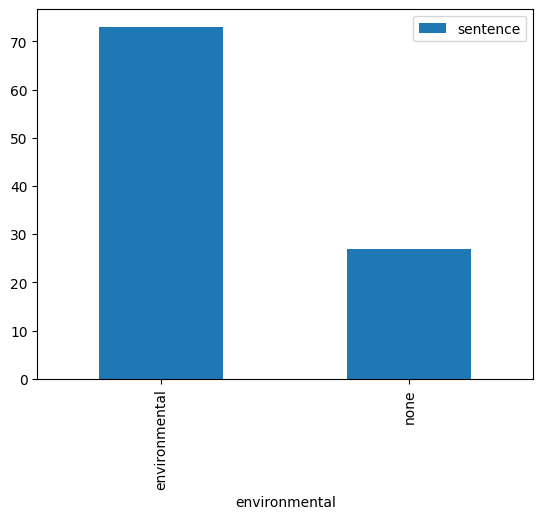

In [45]:
# It could also be interesting to look at the proporation of environmental sentences.
print(data_env_ogfi.groupby("environmental").count())
data_env_ogfi.groupby("environmental").count().plot(kind="bar")

In [47]:
sub_sentences_jpmc = sentences_jpmc[:100] # takes around 20 seconds
env_jpmc = pipe_env(sub_sentences_jpmc, padding=True, truncation=True)

# You might only want the labels.
env_labels_jpmc = [x["label"] for x in env_jpmc]

In [48]:
data_env_jpmc = pd.DataFrame({"sentence": sub_sentences_jpmc, "environmental": env_labels_jpmc})

data_env_jpmc[data_env_jpmc["environmental"] == "environmental"]

,sentence,environmental
0,Facilitating capital and creating investment s...,environmental
1,Our climate-related metrics and targets 22 Sup...,environmental
27,These targets include our portfolio-level carb...,environmental
28,Our targets indicate our intent to capture sus...,environmental
30,These include the necessity of technological a...,environmental
32,"As one example, rising energy demand from data...",environmental
34,"In light of this, we plan to continue to evalu...",environmental
36,The information provided in this report reflec...,environmental
38,"Any references to “sustainable investing”, “su...",environmental
39,Our approach to inclusion of disclosures in th...,environmental


In [49]:
data_env_jpmc.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   sentence       100 non-null    str  
 1   environmental  100 non-null    str  
dtypes: str(2)
memory usage: 1.7 KB


In [50]:
data_env_jpmc['environmental'].unique()

<StringArray>
['environmental', 'none']
Length: 2, dtype: str

               sentence
environmental          
environmental        24
none                 76


<Axes: xlabel='environmental'>

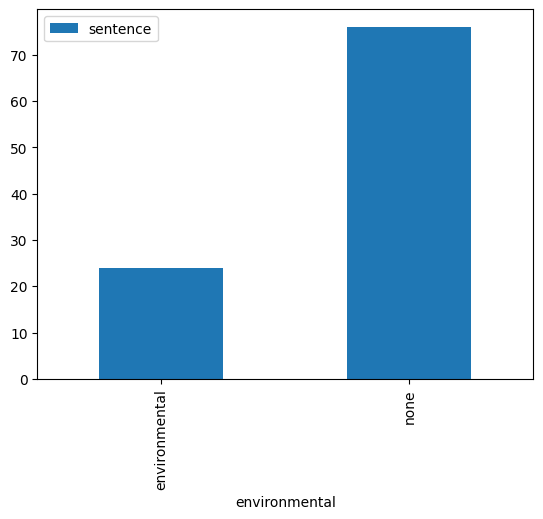

In [51]:
print(data_env_jpmc.groupby("environmental").count())
data_env_jpmc.groupby("environmental").count().plot(kind="bar")

In [52]:
# To load the model, we use the exact same steps as above.
model_name = "climatebert/distilroberta-base-climate-sentiment"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name, max_len=512)
pipe_sent = pipeline("text-classification", model=model, tokenizer=tokenizer)

config.json:   0%|          | 0.00/947 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [53]:
# Use the model on the dataset.
sentiment_jpmc = pipe_sent(sub_sentences_jpmc, padding=True, truncation=True)
# Add the sentiment to the DataFrame.
data_env_jpmc["sentiment"] = [x["label"] for x in sentiment_jpmc]

In [54]:
# Again, have a look at the outcome.
data_env_jpmc[data_env_jpmc["environmental"] == "environmental"]
# Click the first blue symbol that looks like a calculator in the top right of the dataframe to have a closer look.
# Audi seems to display a enthusiastic, pironeering spirit towards sustainability. This positive attitude is reflected as "opportunity".

,sentence,environmental,sentiment
0,Facilitating capital and creating investment s...,environmental,opportunity
1,Our climate-related metrics and targets 22 Sup...,environmental,opportunity
27,These targets include our portfolio-level carb...,environmental,neutral
28,Our targets indicate our intent to capture sus...,environmental,opportunity
30,These include the necessity of technological a...,environmental,risk
32,"As one example, rising energy demand from data...",environmental,neutral
34,"In light of this, we plan to continue to evalu...",environmental,neutral
36,The information provided in this report reflec...,environmental,neutral
38,"Any references to “sustainable investing”, “su...",environmental,neutral
39,Our approach to inclusion of disclosures in th...,environmental,neutral


sentiment
neutral        14
opportunity     9
risk            1
Name: environmental, dtype: int64


<Axes: xlabel='sentiment'>

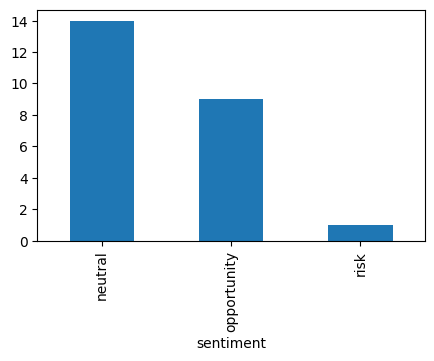

In [55]:
# Let's plot the distribution again.
print(data_env_jpmc[data_env_jpmc["environmental"] == "environmental"].groupby("sentiment").count()["environmental"])
data_env_jpmc[data_env_jpmc["environmental"] == "environmental"].groupby("sentiment").count()["environmental"].plot(kind = "bar", figsize=(5, 3))